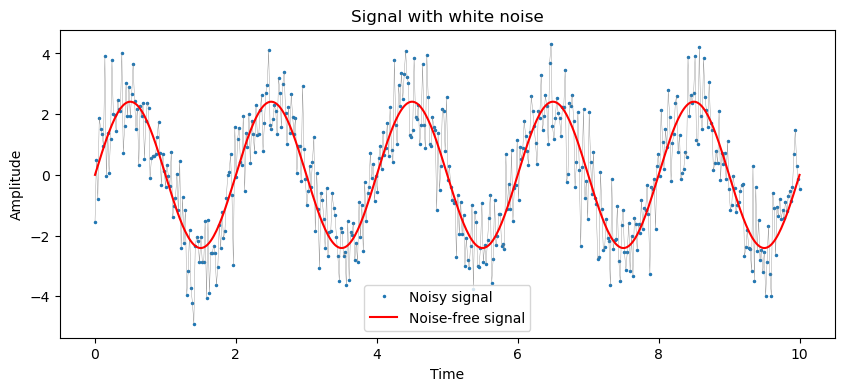

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create the clean signal

# Time axis: 500 evenly spaced samples from 0 to 10 s (both ends included)
t = np.linspace(0, 10, 500)
# Placeholder sine wave: amplitude 2.41, frequency 0.5 Hz (period = 2 s)
signal = 2.41 * np.sin(2 * np.pi * 0.5 * t)  # peak-to-peak = 2 * 2.41 = 4.82

# 2. Add white noise

# Standard deviation of the noise (20% of the peak-to-peak amplitude of the signal)
noise_amplitude = 0.9644505235820642
# White Gaussian noise: mean 0, one independent random value per sample
# (add np.random.seed(0) before this line to get the same noise at every run)
noise = np.random.normal(loc=0, scale=noise_amplitude, size=len(signal))
# The noisy signal is simply the clean signal plus the noise, sample by sample
noisy_signal = signal + noise

# 3. Plot the noisy and the clean signals

plt.figure(figsize=(10, 4))

# Noisy signal as individual points (markersize=3 keeps them small)
plt.plot(t, noisy_signal, '.', markersize=3, label='Noisy signal')
# Same data again as a thin gray line (linewidth=0.25) to help follow the points;
# no label, so it does not appear twice in the legend
plt.plot(t, noisy_signal, linewidth=0.25, color='gray')
# Clean signal in red, for comparison
plt.plot(t, signal, color='red', label='Noise-free signal')

plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Signal with white noise')
plt.legend()
plt.show()

4.2 Plot the remarkable points in the noisy signal

The signal is periodic with a period of about 1 sec.
So the true frequency is about 1Hz
Maximimum is 3 and Minimum is -1.9
Zero crossing negativs at approximativly 0.28 s and 1.28s and posiyive at 0.95s and 1. 95s.

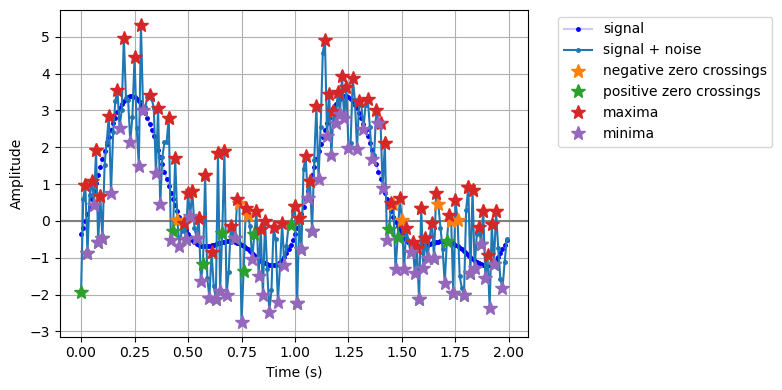

Analysis of the noisy signal:
  delta_zero_crossing_pos (samples) : [57  6  3 37]
  delta_zero_crossing_neg (samples) : [ 3  6  3 79]
  signal_period_pos (s) : 0.2575
  signal_period_neg (s) : 0.2275
  signal_period (s) : 0.2425
  signal_frequency (Hz) : 4.123711340206186


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# 1. Create the clean signal and the noisy signal

# --- Replace these 2 lines with your real t and signal ---
# Time axis: 0 to 2 s (excluded), one sample every 0.01 s -> 200 samples
t = np.arange(0, 2, 0.01)
# Placeholder signal: fundamental (1 Hz) + second harmonic (2 Hz) + constant offset
signal = 2.0 * np.sin(2 * np.pi * (t - 0.0)) + 0.9 * np.sin(4 * np.pi * (t - 0.1)) + 0.5

# Standard deviation of the noise (20% of the peak-to-peak amplitude of the signal)
noise_amplitude = 0.9644505235820642
# White Gaussian noise: mean 0, one independent random value per sample
# (add np.random.seed(0) before this line to get the same noise at every run)
noisy_signal = signal + np.random.normal(0, noise_amplitude, size=len(signal))


# 2. Naive detection functions (no noise handling)

def zero_crossings(y):
    """Return the indices of positive and negative zero crossings of y."""
    # sign() gives -1, 0 or +1 for each sample; a crossing is a change of sign
    s = np.sign(y)
    # s[:-1] = all samples but the last, s[1:] = all samples but the first,
    # so comparing them checks every pair of consecutive samples at once
    pos = np.where((s[:-1] < 0) & (s[1:] >= 0))[0]  # negative -> positive
    neg = np.where((s[:-1] > 0) & (s[1:] <= 0))[0]  # positive -> negative
    return pos, neg


def extrema(y):
    """Return the indices of local maxima and local minima of y."""
    # y[1:-1] = every sample that has a left and a right neighbor
    # y[:-2]  = its left neighbor, y[2:] = its right neighbor
    # A maximum is strictly higher than both neighbors.
    # The "+ 1" converts the index in y[1:-1] back to an index in y.
    maxima = np.where((y[1:-1] > y[:-2]) & (y[1:-1] > y[2:]))[0] + 1
    # A minimum is strictly lower than both neighbors
    minima = np.where((y[1:-1] < y[:-2]) & (y[1:-1] < y[2:]))[0] + 1
    return maxima, minima


# Apply both functions to the noisy signal: noise creates many false detections
pos, neg = zero_crossings(noisy_signal)
imax, imin = extrema(noisy_signal)

# 3. Plot the signals and the detected points

plt.figure(figsize=(8, 4))
plt.axhline(0, color='gray')   # horizontal line at y = 0 to see the zero crossings

# Clean signal: pale line with blue dots
plt.plot(t, signal, '.-', color='#c8c8ff', markerfacecolor='blue',
         markeredgecolor='blue', markersize=5, label='signal')
# Noisy signal: dots joined by a line
plt.plot(t, noisy_signal, '.-', color='tab:blue', markersize=5,
         label='signal + noise')

# Detected points: t[indices] gives the x position, noisy_signal[indices] the y position
plt.plot(t[neg], noisy_signal[neg], '*', color='tab:orange', markersize=10,
         label='negative zero crossings')
plt.plot(t[pos], noisy_signal[pos], '*', color='tab:green', markersize=10,
         label='positive zero crossings')
plt.plot(t[imax], noisy_signal[imax], '*', color='tab:red', markersize=10,
         label='maxima')
plt.plot(t[imin], noisy_signal[imin], '*', color='tab:purple', markersize=10,
         label='minima')

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
# Put the legend outside the plot, on the right
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()   # avoid labels/legend being cut off
plt.show()


# 4. Noise-robust zero crossing detection (hysteresis threshold)

def zero_crossings_clean(y, threshold):
    """
    Return (idx_pos, idx_neg): indices of the negative->positive and
    positive->negative zero crossings, without the duplicates caused by noise.

    A crossing is only validated if the signal has first reached
    +threshold (or -threshold) on the other side of 0.
    """
    idx_pos, idx_neg = [], []
    # Last confirmed side of the signal:
    # 0 = unknown yet, +1 = last confirmed positive, -1 = last confirmed negative
    state = 0

    for i, v in enumerate(y):
        if v > threshold:
            # Signal is clearly positive. If we were confirmed negative before,
            # a real negative -> positive crossing happened.
            if state == -1:
                # Locate the crossing: walk back to the start of the positive run
                # (j ends up on the first positive sample of that run)
                j = i
                while j > 0 and y[j - 1] > 0:
                    j -= 1
                # j - 1 is the last negative sample, i.e. the crossing index
                idx_pos.append(j - 1 if j > 0 else 0)
            state = 1    # now confirmed positive
        elif v < -threshold:
            # Signal is clearly negative: same logic in the other direction
            if state == 1:
                j = i
                while j > 0 and y[j - 1] < 0:
                    j -= 1
                idx_neg.append(j - 1 if j > 0 else 0)
            state = -1   # now confirmed negative
        # If -threshold <= v <= threshold, the signal is in the "dead band"
        # around 0: we do nothing, so small noise wiggles are ignored.

    return np.array(idx_pos), np.array(idx_neg)


# Threshold ~0.96; adjust it (between 0.5x and 2x the noise amplitude):
# too small -> duplicates come back, too large -> real crossings are missed
threshold = noise_amplitude
idx_pos, idx_neg = zero_crossings_clean(noisy_signal, threshold)

# ---------------------------------------------------------------
# 5. Estimate the period and frequency from the crossings
# ---------------------------------------------------------------
dt = t[1] - t[0]   # time step between two samples (s)

# Number of samples between two consecutive crossings of the same type
# (np.diff computes the difference between consecutive elements)
delta_zero_crossing_pos = np.diff(idx_pos)
delta_zero_crossing_neg = np.diff(idx_neg)

# Two consecutive crossings of the same type are one period apart,
# so mean delta (samples) x dt (s per sample) = period in seconds
signal_period_pos = np.mean(delta_zero_crossing_pos) * dt
signal_period_neg = np.mean(delta_zero_crossing_neg) * dt

# Average the two estimates for a more robust period
signal_period = (signal_period_pos + signal_period_neg) / 2

# Frequency is the inverse of the period
signal_frequency = 1 / signal_period

# 6. Print the analysis results

print("Analysis of the noisy signal:")
print(f"  delta_zero_crossing_pos (samples) : {delta_zero_crossing_pos}")
print(f"  delta_zero_crossing_neg (samples) : {delta_zero_crossing_neg}")
print(f"  signal_period_pos (s) : {signal_period_pos}")
print(f"  signal_period_neg (s) : {signal_period_neg}")
print(f"  signal_period (s) : {signal_period}")
print(f"  signal_frequency (Hz) : {signal_frequency}")

4.3 Low pass filter the noisy signal

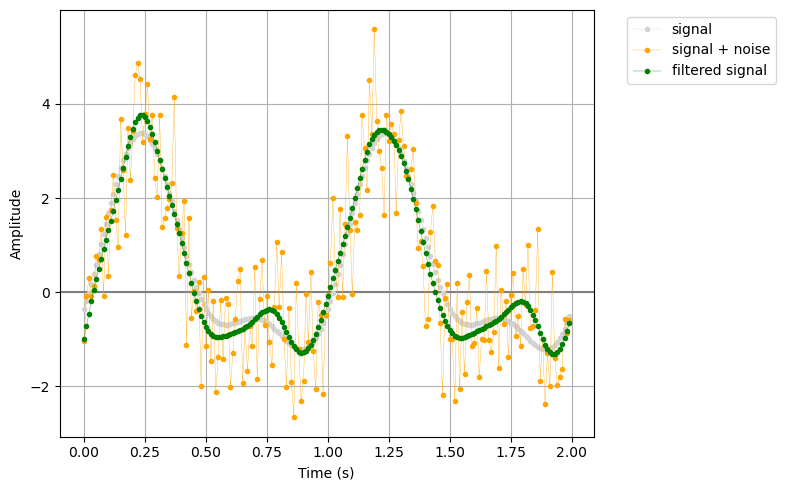

Analysis of noisy signal low pass filtered at 5 Hz:
  delta_zero_crossing_pos (samples) : [97]
  delta_zero_crossing_neg (samples) : [100]
  signal_period_pos (s) : 0.97
  signal_period_neg (s) : 1.0
  signal_period (s) : 0.985
  signal_frequency (Hz) : 1.015228426395939


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# 1. Filter design: Butterworth low-pass filter

# Sampling frequency (Hz) = 1 / time step between two samples
fs = 1 / (t[1] - t[0])   # e.g. 100 Hz if dt = 0.01 s
cutoff = 5               # cutoff frequency (Hz): frequencies above this are attenuated
order = 4                # filter order: higher = sharper transition around the cutoff

# butter() returns the filter coefficients (b = numerator, a = denominator).
# The cutoff must be normalized by the Nyquist frequency (fs / 2),
# i.e. the highest frequency that can be represented at this sampling rate.
b, a = butter(order, cutoff / (fs / 2), btype='low')

# 2. Apply the filter to the noisy signal

# filtfilt applies the filter forward then backward:
# the result has zero phase shift, so the filtered curve stays
# aligned in time with the original signal (no delay).
filtered_signal = filtfilt(b, a, noisy_signal)

# 3. Find the zero crossings of the filtered signal

# sign() gives -1, 0 or +1 for each sample; a crossing is a change of sign
s = np.sign(filtered_signal)

# Positive crossing: sample i is negative and sample i+1 is >= 0
# (s[:-1] = all samples but the last, s[1:] = all samples but the first)
idx_pos = np.where((s[:-1] < 0) & (s[1:] >= 0))[0]   # negative -> positive

# Negative crossing: sample i is positive and sample i+1 is <= 0
idx_neg = np.where((s[:-1] > 0) & (s[1:] <= 0))[0]   # positive -> negative

# 4. Estimate the period and frequency from the crossings

dt = t[1] - t[0]   # time step between two samples (s)

# Number of samples between two consecutive crossings of the same type
# (np.diff computes the difference between consecutive elements)
delta_zero_crossing_pos = np.diff(idx_pos)
delta_zero_crossing_neg = np.diff(idx_neg)

# Two consecutive positive (or negative) crossings are exactly one period apart,
# so the mean delta (in samples) x dt (s per sample) = period in seconds
signal_period_pos = np.mean(delta_zero_crossing_pos) * dt
signal_period_neg = np.mean(delta_zero_crossing_neg) * dt

# Average the two estimates for a more robust period
signal_period = (signal_period_pos + signal_period_neg) / 2

# Frequency is the inverse of the period
signal_frequency = 1 / signal_period

# 5. Plot the three signals

plt.figure(figsize=(8, 5))
plt.axhline(0, color='gray')   # horizontal line at y = 0 to see the zero crossings

# linewidth=0.25 gives a thin line connecting the dots
plt.plot(t, signal, '.-', color='lightgray', linewidth=0.25, label='signal')
plt.plot(t, noisy_signal, '.-', color='orange', linewidth=0.25, label='signal + noise')
plt.plot(t, filtered_signal, '.-', color='green', linewidth=0.25, label='filtered signal')

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

# Put the legend outside the plot, on the right
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()   # avoid labels/legend being cut off
plt.show()

# 6. Print the analysis results

print(f"Analysis of noisy signal low pass filtered at {cutoff} Hz:")
print(f"  delta_zero_crossing_pos (samples) : {delta_zero_crossing_pos}")
print(f"  delta_zero_crossing_neg (samples) : {delta_zero_crossing_neg}")
print(f"  signal_period_pos (s) : {signal_period_pos}")
print(f"  signal_period_neg (s) : {signal_period_neg}")
print(f"  signal_period (s) : {signal_period}")
print(f"  signal_frequency (Hz) : {signal_frequency}")